## HOG (Histogram of Oriented Gradients)

In [1]:
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

In [2]:
img = cv2.imread("../../assets/sus.png")
print(img)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


In [3]:
# # BGR -> RGB
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
# tgb -> grayscale
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [5]:
print(gray)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [6]:
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm="L2-Hys"
)

In [7]:
# improving hog image contrast
hog_image = exposure.rescale_intensity(hog_image,in_range=(0,10))

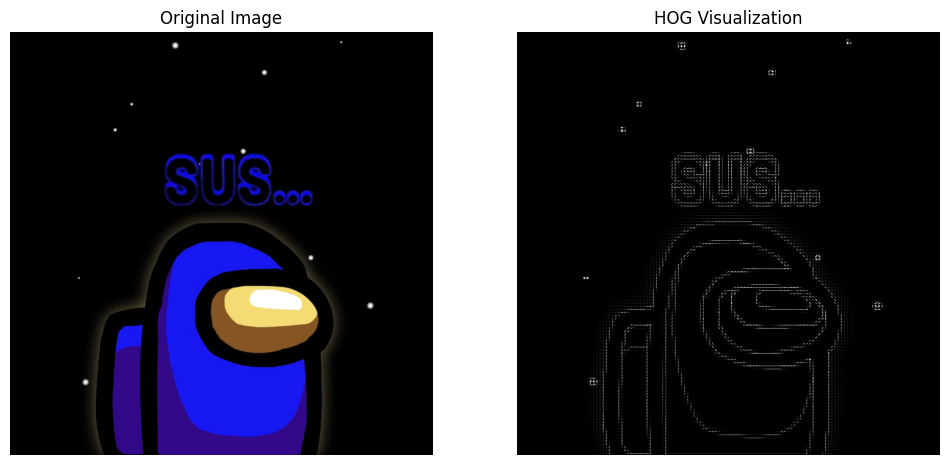

Feature vector length: 646416


In [8]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")

plt.show()

print("Feature vector length:", len(features))

## LBP (Local Binary Pattern)

In [44]:
# LBP parameters
radius = 1
n_points = 8 * radius

In [46]:
from skimage.feature import local_binary_pattern
lbp = local_binary_pattern(gray, n_points, radius, method="uniform")

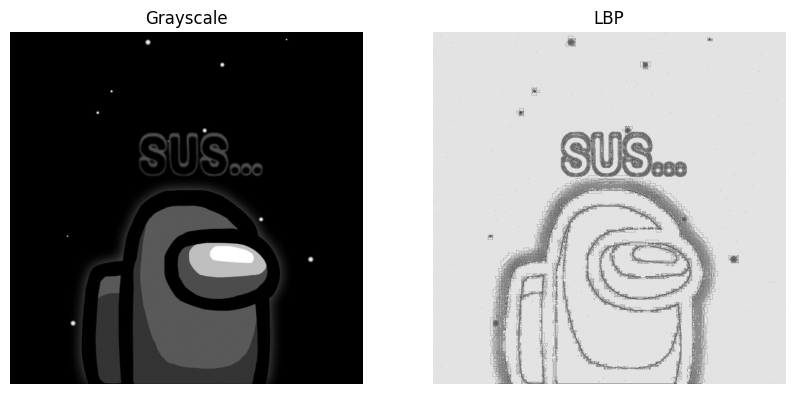

In [47]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lbp, cmap="gray")
plt.title("LBP")
plt.axis("off")

plt.show()

In [48]:
import numpy as np

hist, _ = np.histogram(
    lbp.ravel(),
    bins=np.arange(0, n_points + 3),
    range=(0, n_points + 2)
)

# Normalize histogram
hist = hist.astype("float")
hist /= (hist.sum() + 1e-6)

print(hist)

[0.00164695 0.00514918 0.00107596 0.01103138 0.03263632 0.04581704
 0.00530864 0.00770576 0.88199331 0.00763546]
